# Taller de Inteligencia Artificial
Predicción de la concentración de Plomo (Pb) mediante Regresión En este taller se analiza un conjunto de datos de calidad del aire de la estación **TROY LEAD** (Troy, Alabama, EE.UU.), con mediciones durante el año **2023**. La variable que se desea predecir es la **concentración media diaria de plomo en el aire (µg/m3)**, a partir de variables derivadas de la fecha (mes, día de la semana, estacionalidad anual) y del identificador de sonda (POC) con el que se registró cada medición. Primero se realiza una limpieza y exploración de los datos para conocer su distribución y las relaciones entre las variables, utilizando histogramas, series de tiempo y mapas de calor. A partir de los datos obtenidos, se prepara la información para construir modelos de aprendizaje automático. Se implementa una **Regresión Lineal** , un **Árbol de Decisión** y un **Random Forest**, buscando estimar la concentración de plomo a partir de las variables disponibles. Finalmente, se comparan los valores reales con las predicciones obtenidas y se analizan los residuos para observar el comportamiento de los modelos.

## Importamos los paquetes

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
sns.set_style("whitegrid")

## Cargamos el conjunto de datos

In [3]:
df_crudo = pd.read_csv("Lead_daily_aqs_data_downloaded_2026-09-18 19_45_02.csv")
df_crudo.head()

,Date,Site ID,POC,Daily Mean Lead Concentration,Units,Daily AQI Value,Local Site Name,Daily Obs Count,Percent Complete,AQS Parameter Code,...,Elevation (m),Measurement Scale,Measurement Scale Definition,Monitor Type,Monitoring Agency,Monitoring Objective,NAAQS Primary Monitor?,Networks,Probe Height (m),QA Primary Monitor?
0,2023-01-06,11090003,1,0.034,Micrograms/cubic meter (LC),NaN,TROY LEAD,1,100,14129,...,161,NEIGHBORHOOD,500 M TO 4KM,SLAMS,Al Dept Of Env Mgt,HIGHEST CONCENTRATION; SOURCE ORIENTED,Y,NaN,3,Y
1,2023-01-12,11090003,1,0.033,Micrograms/cubic meter (LC),NaN,TROY LEAD,1,100,14129,...,161,NEIGHBORHOOD,500 M TO 4KM,SLAMS,Al Dept Of Env Mgt,HIGHEST CONCENTRATION; SOURCE ORIENTED,Y,NaN,3,Y
2,2023-01-18,11090003,1,0.133,Micrograms/cubic meter (LC),NaN,TROY LEAD,1,100,14129,...,161,NEIGHBORHOOD,500 M TO 4KM,SLAMS,Al Dept Of Env Mgt,HIGHEST CONCENTRATION; SOURCE ORIENTED,Y,NaN,3,Y
3,2023-01-24,11090003,1,0.184,Micrograms/cubic meter (LC),NaN,TROY LEAD,1,100,14129,...,161,NEIGHBORHOOD,500 M TO 4KM,SLAMS,Al Dept Of Env Mgt,HIGHEST CONCENTRATION; SOURCE ORIENTED,Y,NaN,3,Y
4,2023-01-30,11090003,1,0.056,Micrograms/cubic meter (LC),NaN,TROY LEAD,1,100,14129,...,161,NEIGHBORHOOD,500 M TO 4KM,SLAMS,Al Dept Of Env Mgt,HIGHEST CONCENTRATION; SOURCE ORIENTED,Y,NaN,3,Y


## Consultamos la información básica del conjunto de datos

In [4]:
df_crudo.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 106 entries, 0 to 105
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Date                           106 non-null    object 
 1   Site ID                        106 non-null    int64  
 2   POC                            106 non-null    int64  
 3   Daily Mean Lead Concentration  106 non-null    float64
 4   Units                          106 non-null    object 
 5   Daily AQI Value                0 non-null      float64
 6   Local Site Name                106 non-null    object 
 7   Daily Obs Count                106 non-null    int64  
 8   Percent Complete               106 non-null    int64  
 9   AQS Parameter Code             106 non-null    int64  
 10  AQS Parameter Description      106 non-null    object 
 11  Method Code                    106 non-null    int64  
 12  Method Description             106 non-null    obj

Revisamos cuántos valores distintos tiene cada columnaEste paso es importante: si una columna tiene **un solo valor distinto**, no aporta información al modelo (por ejemplo, todos los registros pertenecen a la misma estación de monitoreo o vienen en la misma unidad).

In [12]:
df_crudo.nunique()

,0
Date,60
Site ID,1
POC,2
Daily Mean Lead Concentration,75
Units,1
Daily AQI Value,0
Local Site Name,1
Daily Obs Count,1
Percent Complete,1
AQS Parameter Code,1


**Limpieza y preparación de datos**Se eliminan las columnas constantes (estación, estado, coordenadas, unidades, método de medición) y se renombran las variables de interés a nombres más cortos. Además, se derivan las siguientes características a partir de la fecha:* **Mes**: Mes del año (1 a 12).* **Dia_Año**: Día del año (1 a 365).* **Dia_Semana**: Día de la semana (0 = lunes, 6 = domingo).* **Fin_Semana**: Variable binaria (1 para fin de semana, 0 en caso contrario).* **Sen_Anual / Cos_Anual**: Transformación cíclica que captura la estacionalidad anual, dando continuidad entre diciembre y enero para el modelo lineal.También se conserva `Codigo_Sonda` (columna `POC`), que en este archivo identifica con qué sonda del monitor se tomó cada muestra y sí presenta variación entre registros.

In [14]:
df = df_crudo.copy()
# Convertimos la fecha a tipo datetime
df["Date"] = pd.to_datetime(df["Date"], format="%Y-%m-%d")
# Renombramos las columnas de interés
df = df.rename(columns={
    "Daily Mean Lead Concentration": "Pb_ugm3",
    "Daily AQI Value": "AQI",
    "POC": "Codigo_Sonda"
})
# Creamos las variables derivadas de la fecha
df["Mes"] = df["Date"].dt.month
df["Dia_Anio"] = df["Date"].dt.dayofyear
df["Dia_Semana"] = df["Date"].dt.dayofweek
df["Fin_Semana"] = (df["Dia_Semana"] >= 5).astype(int)
df["Sen_Anual"] = np.sin(2 * np.pi * df["Dia_Anio"] / 365)
df["Cos_Anual"] = np.cos(2 * np.pi * df["Dia_Anio"] / 365)
df[["Date", "Pb_ugm3", "AQI", "Mes", "Dia_Anio", "Dia_Semana", "Codigo_Sonda"]].head()

,Date,Pb_ugm3,AQI,Mes,Dia_Anio,Dia_Semana,Codigo_Sonda
0,2023-01-06,0.034,NaN,1,6,4,1
1,2023-01-12,0.033,NaN,1,12,3,1
2,2023-01-18,0.133,NaN,1,18,2,1
3,2023-01-24,0.184,NaN,1,24,1,1
4,2023-01-30,0.056,NaN,1,30,0,1


## Verificamos valores faltantes

In [17]:
df.isnull().sum().sum()

np.int64(324)

**Selección de variables del modelo**Se ubica la variable objetivo (`Pb_ugm3`) al final del DataFrame para facilitar la separación entre las variables de entrada y la variable a predecir.> **Nota:** Se excluye la columna `AQI` debido a que el Índice de Calidad del Aire se calcula directamente a partir de la propia concentración de plomo (en este archivo, de hecho, ni siquiera se reporta). Incluirla generaría una fuga de información (*data leakage*), resultando en un modelo trivial con resultados irreales.

In [15]:
variables_modelo = ["Mes", "Dia_Semana", "Fin_Semana", "Sen_Anual", "Cos_Anual","Codigo_Sonda", "Pb_ugm3"]
datos = df[variables_modelo].copy()
datos.head()

,Mes,Dia_Semana,Fin_Semana,Sen_Anual,Cos_Anual,Codigo_Sonda,Pb_ugm3
0,1,4,0,0.103102,0.994671,1,0.034
1,1,3,0,0.205104,0.978740,1,0.033
2,1,2,0,0.304921,0.952378,1,0.133
3,1,1,0,0.401488,0.915864,1,0.184
4,1,0,0,0.493776,0.869589,1,0.056


## Obtenemos un resumen estadístico de las variables

In [18]:
datos.describe().round(3)

,Mes,Dia_Semana,Fin_Semana,Sen_Anual,Cos_Anual,Codigo_Sonda,Pb_ugm3
count,106.000,106.000,106.000,106.000,106.000,106.000,106.000
mean,6.321,2.953,0.264,0.058,0.014,1.528,0.112
std,3.517,1.973,0.443,0.713,0.706,0.502,0.188
min,1.000,0.000,0.000,-0.999,-0.999,1.000,0.002
25%,3.000,1.000,0.000,-0.644,-0.645,1.000,0.021
50%,6.000,3.000,0.000,0.124,-0.021,2.000,0.049
75%,9.000,5.000,1.000,0.764,0.735,2.000,0.116
max,12.000,6.000,1.000,1.000,0.996,2.000,1.237


## Identificamos las características del conjunto de datos

In [19]:
datos.columns

Index(['Mes', 'Dia_Semana', 'Fin_Semana', 'Sen_Anual', 'Cos_Anual',
       'Codigo_Sonda', 'Pb_ugm3'],
      dtype='object')

## Visualización Básica

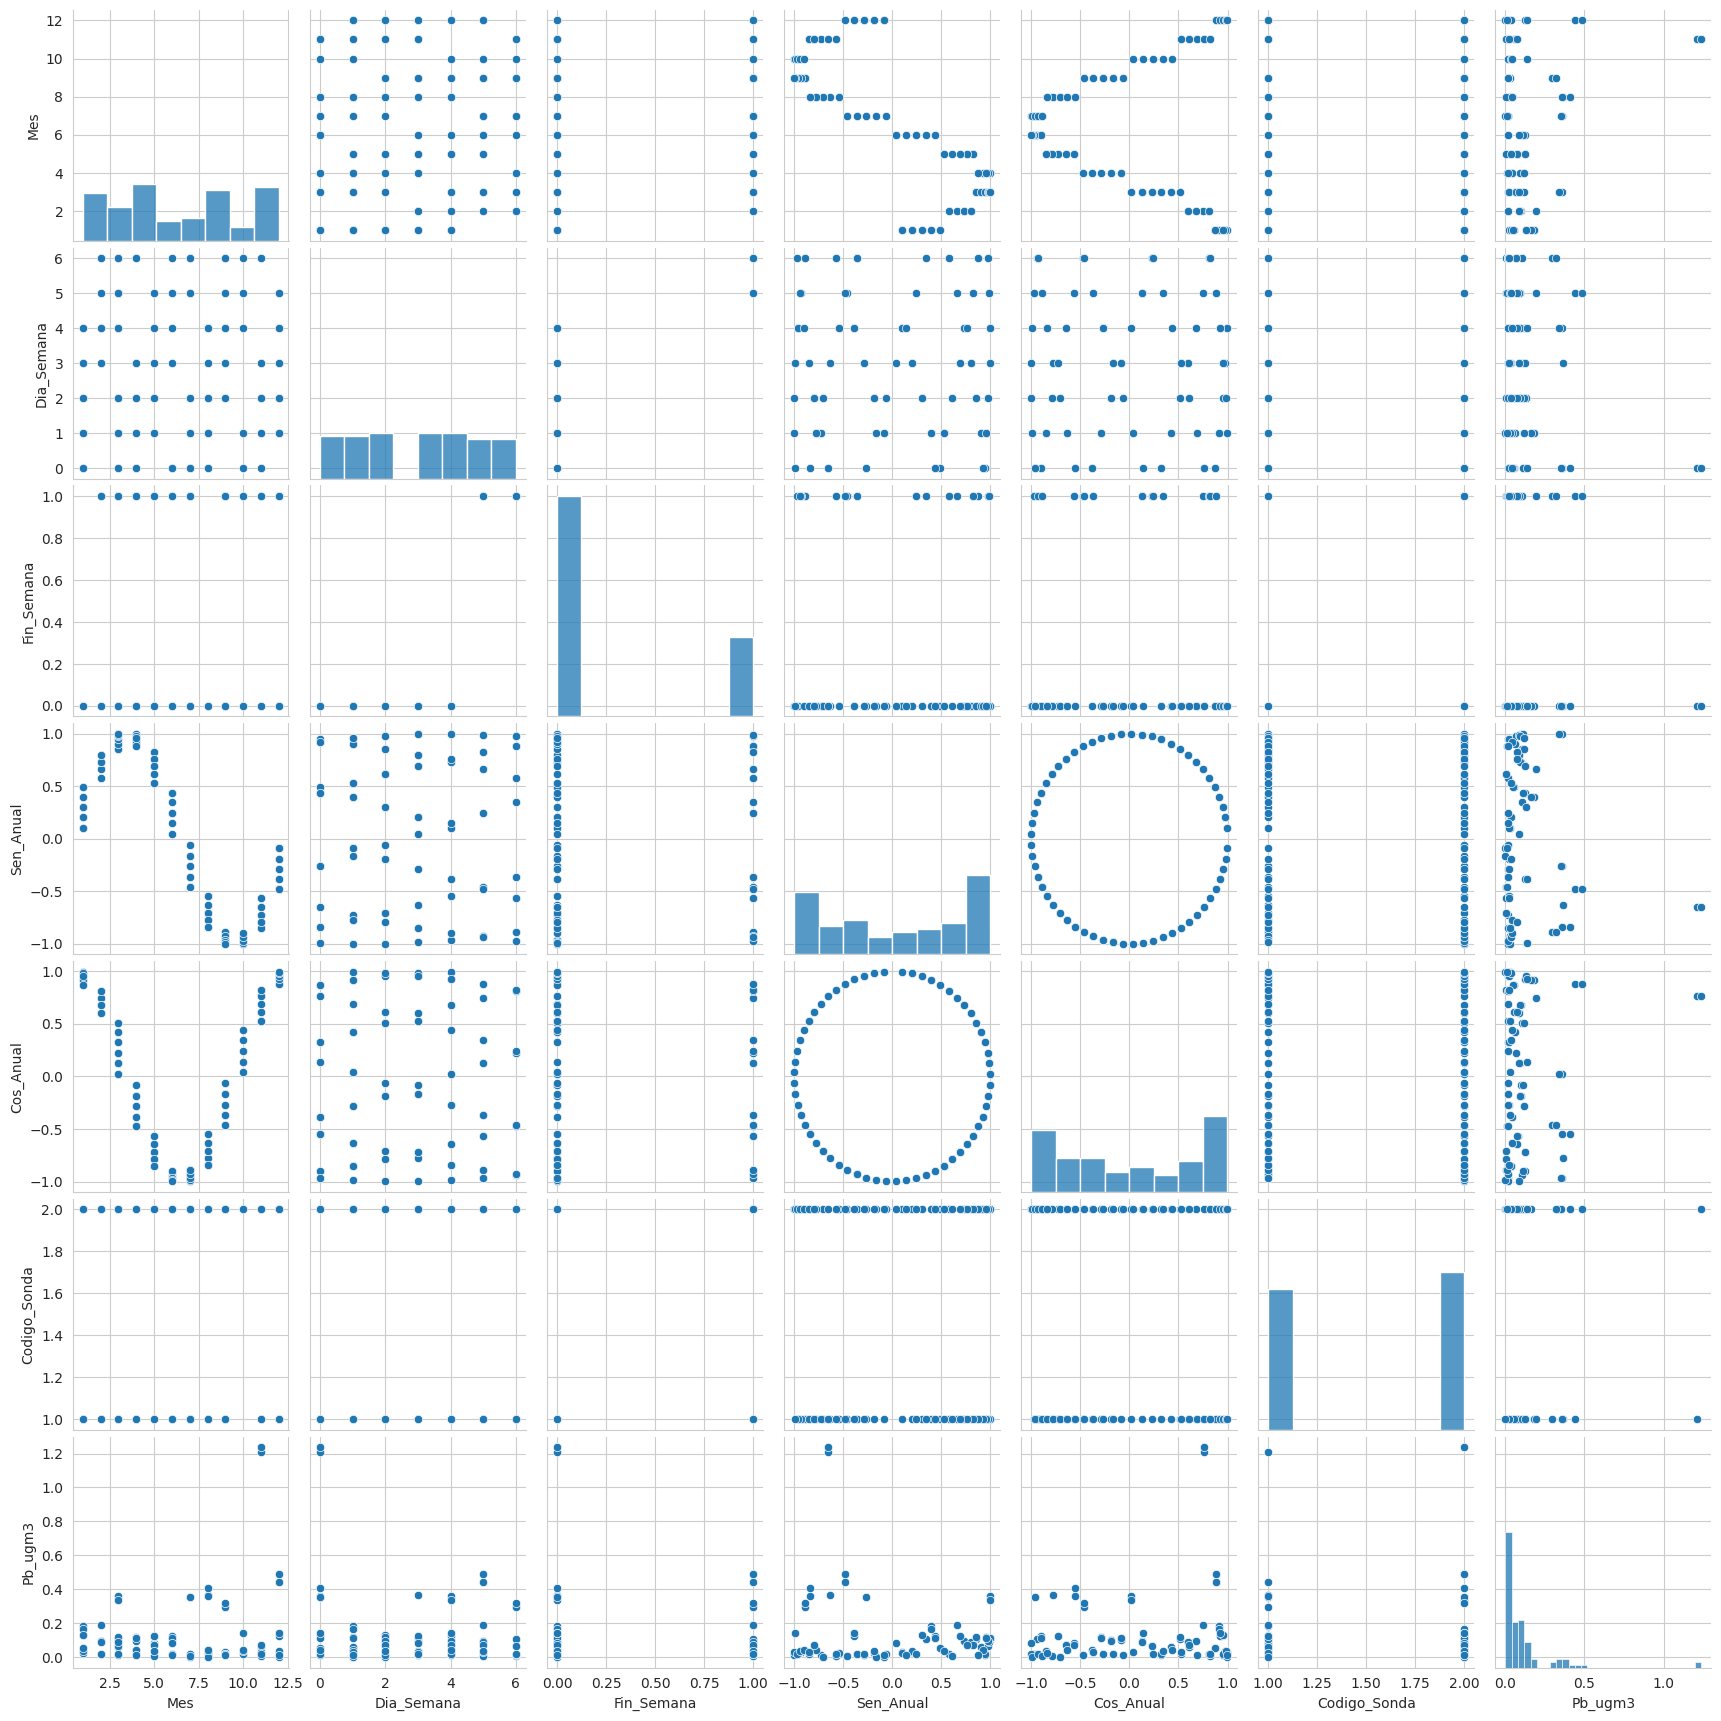

In [21]:
# Visualizamos la relación entre todas las variables del conjunto de datos
sns.pairplot(datos)

## Distribución de la concentración de plomo

Text(0.5, 1.0, 'Histograma de la concentración diaria de plomo')

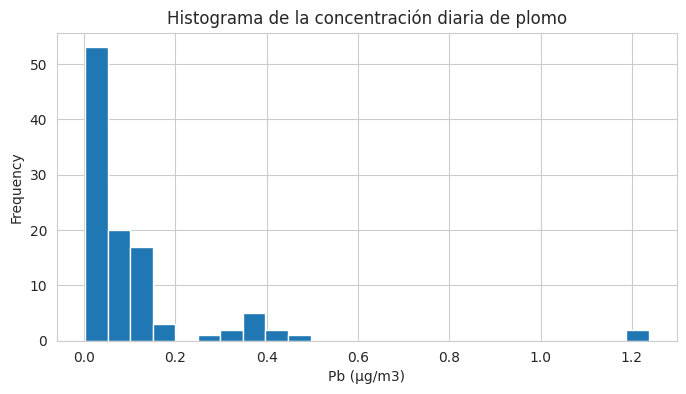

In [22]:
datos["Pb_ugm3"].plot.hist(bins=25, figsize=(8, 4))
plt.xlabel("Pb (µg/m3)")
plt.title("Histograma de la concentración diaria de plomo")

'\nDensidad: ¿Dónde están concentrados los datos?\n\n'

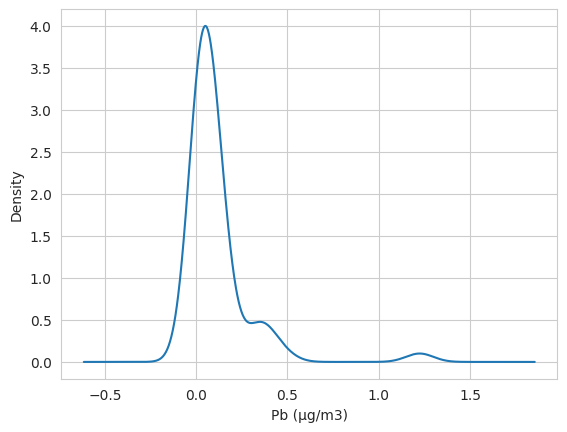

In [23]:
# Estimamos la distribución de la concentración de plomo
datos["Pb_ugm3"].plot.density()
plt.xlabel("Pb (µg/m3)")
"""
Densidad: ¿Dónde están concentrados los datos?

"""

**Evolución anual de la concentración de plomo**Al tratarse de una serie de tiempo, permite analizar la variación de la variable a lo largo del año. La estación TROY LEAD mide plomo aproximadamente una vez por semana, por lo que la serie se ve más espaciada que en un contaminante medido a diario.

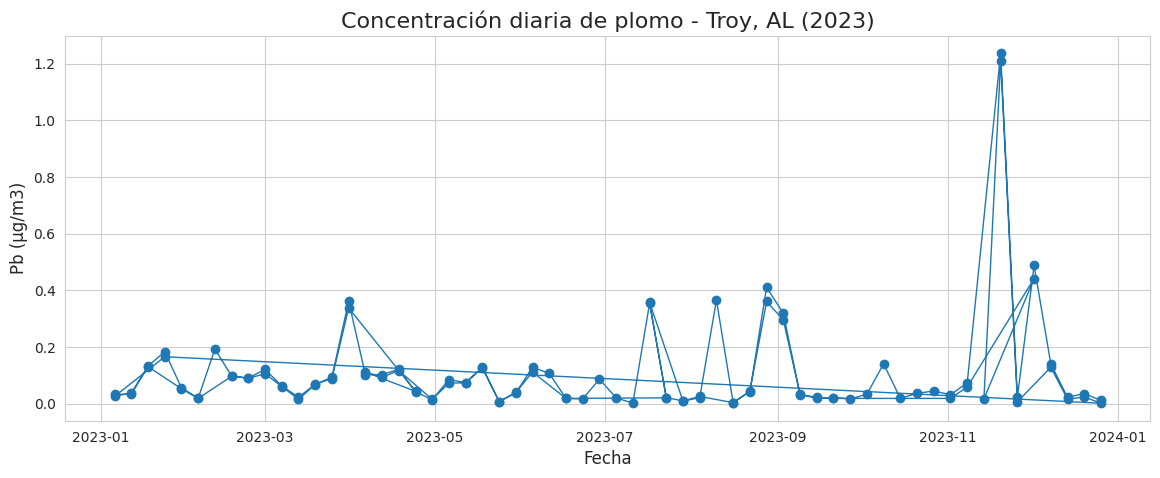

In [24]:
plt.figure(figsize=(14, 5))
plt.plot(df["Date"], df["Pb_ugm3"], marker="o", linewidth=1)
plt.title("Concentración diaria de plomo - Troy, AL (2023)", fontsize=16)
plt.xlabel("Fecha", fontsize=12)
plt.ylabel("Pb (µg/m3)", fontsize=12)
plt.show()

## Promedio mensual de plomo

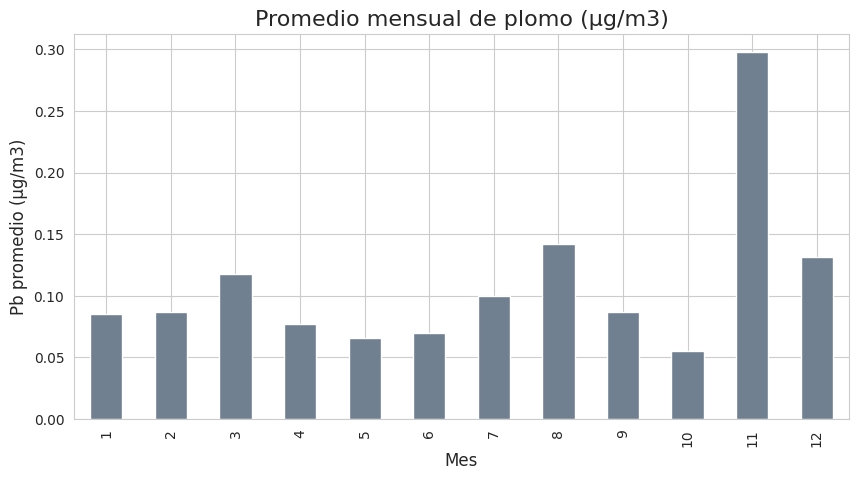

,Pb_ugm3
Mes,
1,0.085
2,0.087
3,0.118
4,0.077
5,0.066
6,0.070
7,0.100
8,0.142
9,0.087


In [26]:
promedio_mensual = df.groupby("Mes")["Pb_ugm3"].mean()
plt.figure(figsize=(10, 5))
promedio_mensual.plot(kind="bar", color="slategray")
plt.title("Promedio mensual de plomo (µg/m3)", fontsize=16)
plt.xlabel("Mes", fontsize=12)
plt.ylabel("Pb promedio (µg/m3)", fontsize=12)
plt.show()
promedio_mensual.round(3)

# Matriz de correlación y heatmap

<strong> Análisis de correlación entre las variables <strong>

In [27]:
# Seleccionamos las variables numéricas del conjunto de datos
numeric_df = datos.select_dtypes(include=[np.number])
# Calculamos la matriz de correlación
numeric_df.corr().round(4)

,Mes,Dia_Semana,Fin_Semana,Sen_Anual,Cos_Anual,Codigo_Sonda,Pb_ugm3
Mes,1.0000,0.0296,0.0429,-0.7816,0.0009,0.0542,0.1600
Dia_Semana,0.0296,1.0000,0.7772,-0.0366,-0.0320,-0.0227,-0.2072
Fin_Semana,0.0429,0.7772,1.0000,-0.0269,-0.1085,-0.0340,-0.0575
Sen_Anual,-0.7816,-0.0366,-0.0269,1.0000,0.0146,-0.0777,-0.1223
Cos_Anual,0.0009,-0.0320,-0.1085,0.0146,1.0000,-0.0355,0.1122
Codigo_Sonda,0.0542,-0.0227,-0.0340,-0.0777,-0.0355,1.0000,-0.0386
Pb_ugm3,0.1600,-0.2072,-0.0575,-0.1223,0.1122,-0.0386,1.0000


<strong> Mapa de calor <strong>

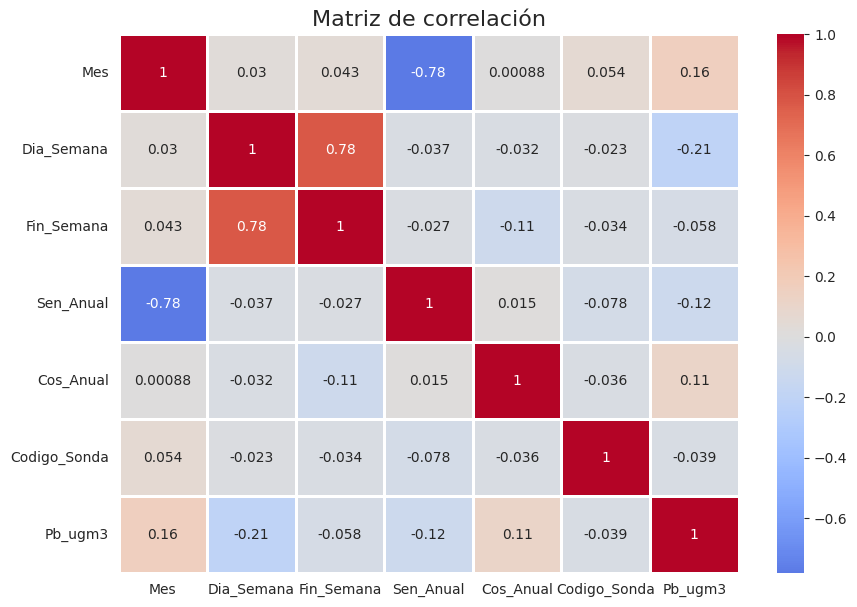

In [43]:
# Representamos visualmente la matriz de correlación
plt.figure(figsize=(10, 7))
sns.heatmap(numeric_df.corr(), annot=True, linewidths=2, cmap="coolwarm", center=0)
plt.title("Matriz de correlación", fontsize=16)
plt.show()

<strong> Definición de variables para el modelo <strong>

In [45]:
# Obtenemos los nombres de las variables
l_column = list(datos.columns)
# Contamos la cantidad de variables
len_feature = len(l_column)
l_column

['Mes',
 'Dia_Semana',
 'Fin_Semana',
 'Sen_Anual',
 'Cos_Anual',
 'Codigo_Sonda',
 'Pb_ugm3']

In [47]:
# Definimos las variables de entrada y la variable objetivo
x = datos[l_column[0:len_feature-1]]
y = datos[l_column[len_feature-1]]
x.head()

,Mes,Dia_Semana,Fin_Semana,Sen_Anual,Cos_Anual,Codigo_Sonda
0,1,4,0,0.103102,0.994671,1
1,1,3,0,0.205104,0.978740,1
2,1,2,0,0.304921,0.952378,1
3,1,1,0,0.401488,0.915864,1
4,1,0,0,0.493776,0.869589,1


In [48]:
y.head()

,Pb_ugm3
0,0.034
1,0.033
2,0.133
3,0.184
4,0.056


# Dividimos entrenamiento-prueba

<strong> División de los datos <strong>

In [49]:
from sklearn.model_selection import train_test_split

In [50]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.3, random_state=7
)
print("Datos de entrenamiento:", x_train.shape)
print("Datos de prueba:", x_test.shape)

Datos de entrenamiento: (74, 6)
Datos de prueba: (32, 6)


# Ajuste y entrenamiento del modelo

<strong> Ajuste del modelo de Regresión Lineal <strong>

In [52]:
from sklearn.linear_model import LinearRegression
from sklearn import metrics
lm = LinearRegression()

In [53]:
lm.fit(x_train, y_train)

LinearRegression()

In [54]:
print("El término de intersección del modelo lineal:", lm.intercept_)

El término de intersección del modelo lineal: 0.17053995760352936


<strong> Obtención de los coeficientes del modelo <strong>

In [55]:
print("Los coeficientes del modelo lineal:", lm.coef_)

Los coeficientes del modelo lineal: [ 0.01551312 -0.05165776  0.17835092 -0.00169286  0.06697258 -0.02131454]


In [56]:
cdf = pd.DataFrame(data=lm.coef_, index=x_train.columns, columns=["Coeficientes"])
cdf

,Coeficientes
Mes,0.015513
Dia_Semana,-0.051658
Fin_Semana,0.178351
Sen_Anual,-0.001693
Cos_Anual,0.066973
Codigo_Sonda,-0.021315


<strong> Error estándar y estadístico t de los coeficientes <strong>El estadístico **t** indica qué tan significativa es cada variable: entre más grande sea su valor absoluto, más confianza tenemos en que esa variable realmente influye sobre la concentración de plomo.

In [57]:
# Obtenemos el número de observaciones y variables
n = x_train.shape[0]
k = x_train.shape[1]
dfN = n - k
# Generamos las predicciones del conjunto de entrenamiento
train_pred = lm.predict(x_train)
# Calculamos el error cuadrático total
train_error = np.square(train_pred - y_train)
sum_error = np.sum(train_error)
# Calculamos el error estándar de cada coeficiente
se = [0] * k
for i in range(k):
    col = list(x_train.columns)[i]
    r = (sum_error / dfN)
    r = r / np.sum(np.square(x_train[col] - x_train[col].mean()))
    se[i] = np.sqrt(r)
cdf["Error Estandar"] = se
cdf["Estadistico-t"] = cdf["Coeficientes"] / cdf["Error Estandar"]
cdf.round(4)

,Coeficientes,Error Estandar,Estadistico-t
Mes,0.0155,0.0069,2.2549
Dia_Semana,-0.0517,0.0122,-4.2301
Fin_Semana,0.1784,0.0564,3.1619
Sen_Anual,-0.0017,0.0342,-0.0495
Cos_Anual,0.0670,0.0330,2.0289
Codigo_Sonda,-0.0213,0.0475,-0.4485


<strong> Relación entre las variables y la concentración de plomo <strong>

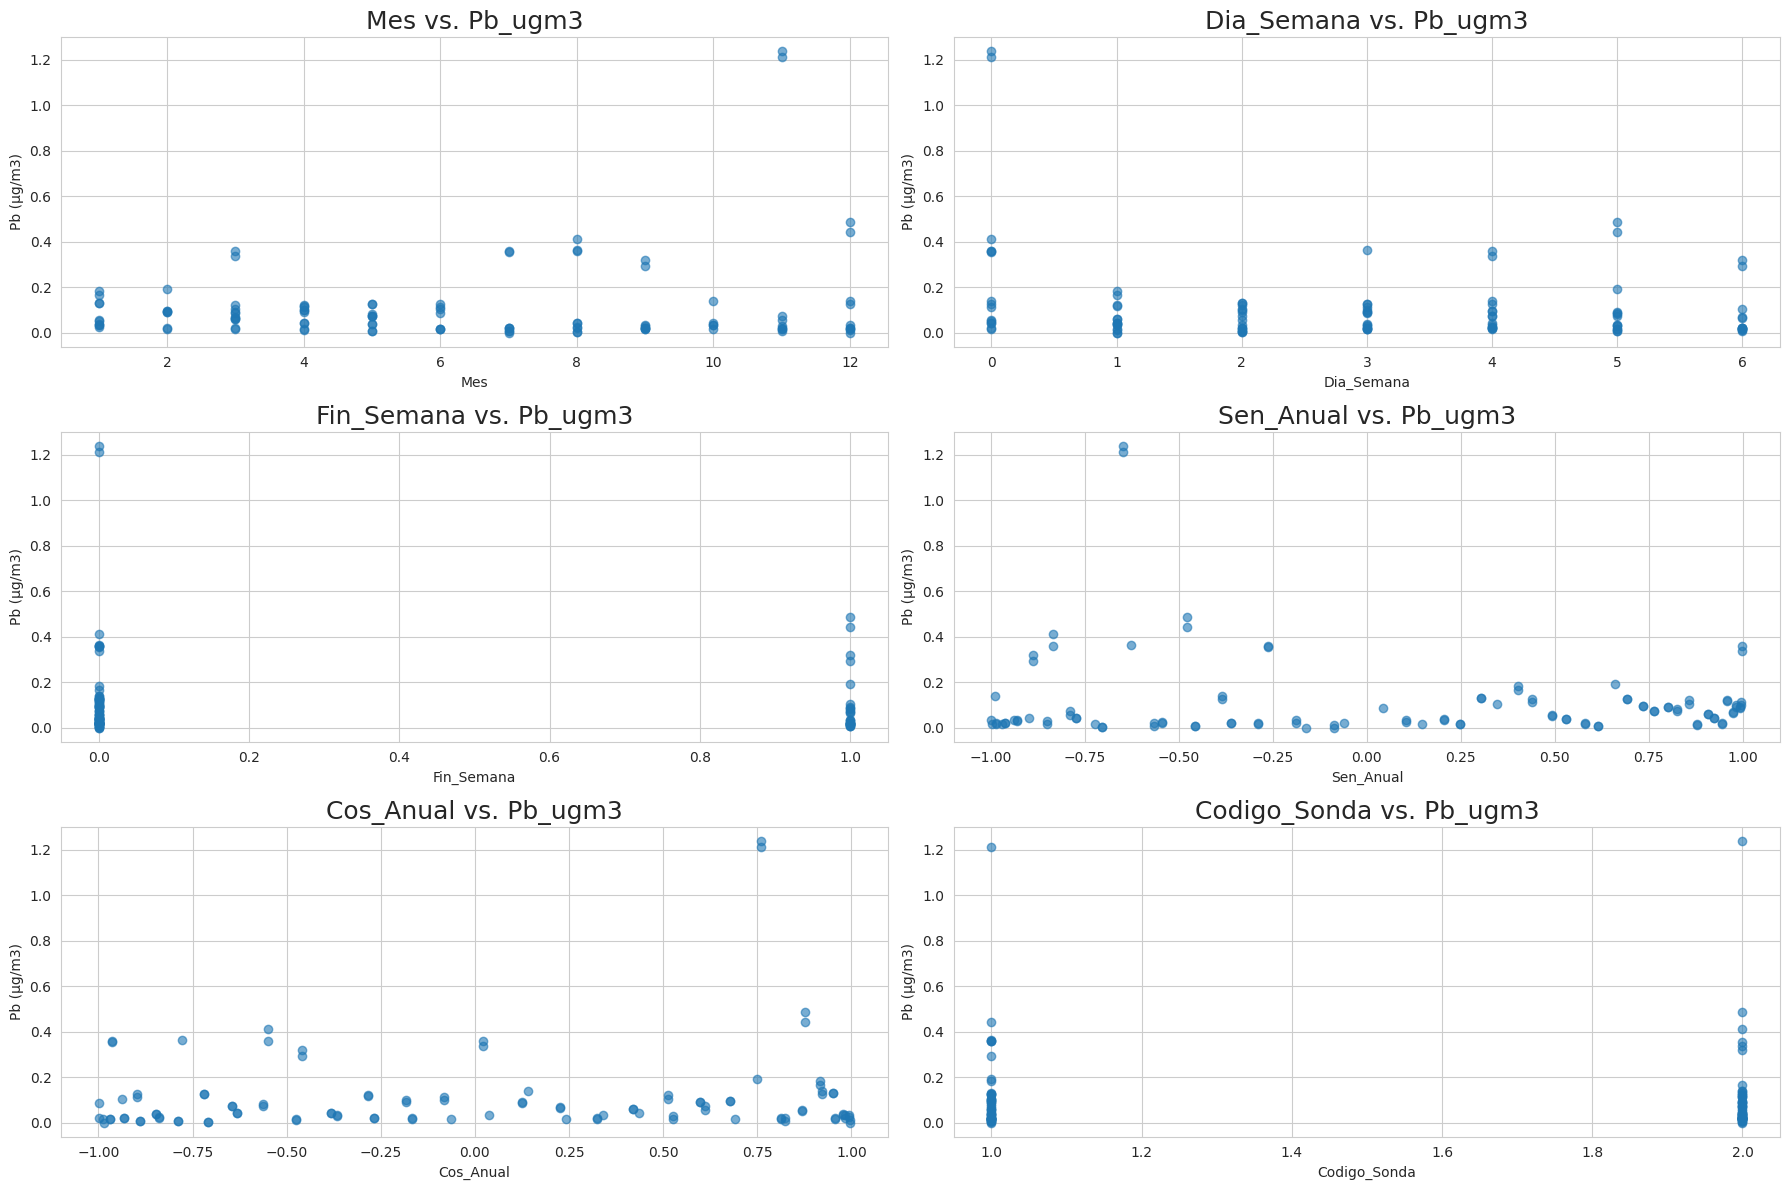

In [58]:
l = list(cdf.index)
from matplotlib import gridspec
fig = plt.figure(figsize=(18, 12))
gs = gridspec.GridSpec(3, 2)
for i in range(len(l)):
    ax = plt.subplot(gs[i])
    ax.scatter(datos[l[i]], datos["Pb_ugm3"], alpha=0.6)
    ax.set_title(l[i] + " vs. Pb_ugm3", fontdict={"fontsize": 18})
    ax.set_xlabel(l[i])
    ax.set_ylabel("Pb (µg/m3)")
plt.tight_layout()
plt.show()

## Matrices de evaluación de estimación de error

<strong> Generación y evaluación de las predicciones <strong>

In [59]:
predictions = lm.predict(x_test)
print("Tipo del objeto predicho :", type(predictions))
print("Tamaño del objeto predicho:", predictions.shape)

Tipo del objeto predicho : <class 'numpy.ndarray'>
Tamaño del objeto predicho: (32,)


In [60]:
print("MAE  (Error absoluto medio):  ", round(metrics.mean_absolute_error(y_test, predictions), 4))
print("MSE  (Error cuadrático medio):", round(metrics.mean_squared_error(y_test, predictions), 4))
print("RMSE (Raíz del MSE):          ", round(float(np.sqrt(metrics.mean_squared_error(y_test, predictions))), 4))
print("R2   (Coeficiente de determinación):", round(metrics.r2_score(y_test, predictions), 4))

MAE  (Error absoluto medio):   0.1125
MSE  (Error cuadrático medio): 0.0202
RMSE (Raíz del MSE):           0.1422
R2   (Coeficiente de determinación): -3.0954


El **R²** indica qué porcentaje de la variación del plomo logra explicar el modelo. Un valor cercano a 1 significa un ajuste muy bueno, y cercano a 0 (o negativo) que el modelo casi no explica el comportamiento de los datos.

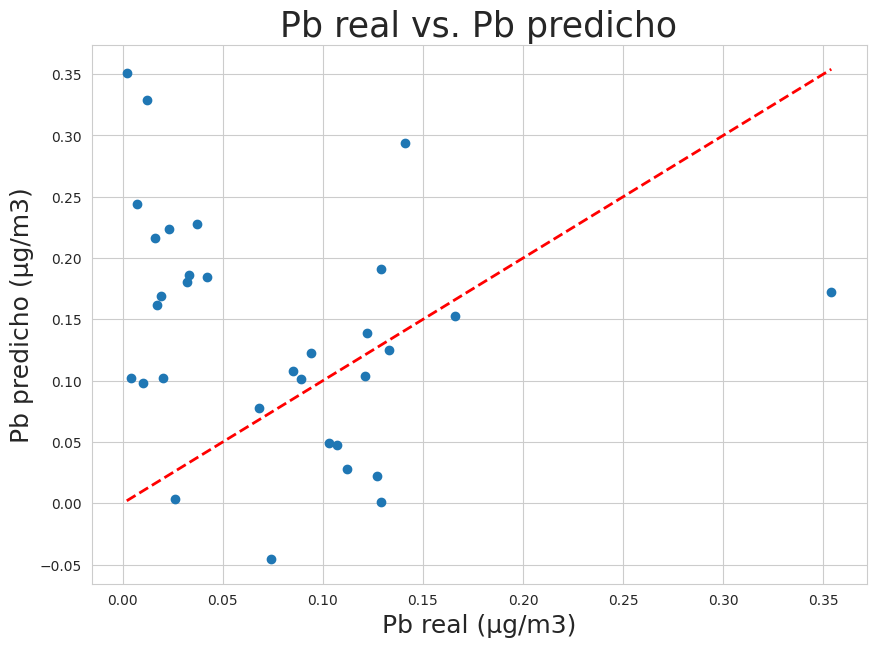

In [61]:
""" DIAGRAMA DE DISPERSIÓN """
plt.figure(figsize=(10, 7))
plt.title("Pb real vs. Pb predicho", fontsize=25)
plt.xlabel("Pb real (µg/m3)", fontsize=18)
plt.ylabel("Pb predicho (µg/m3)", fontsize=18)
plt.scatter(x=y_test, y=predictions)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--", linewidth=2)
plt.show()

<strong> Análisis de los residuos del modelo <strong>

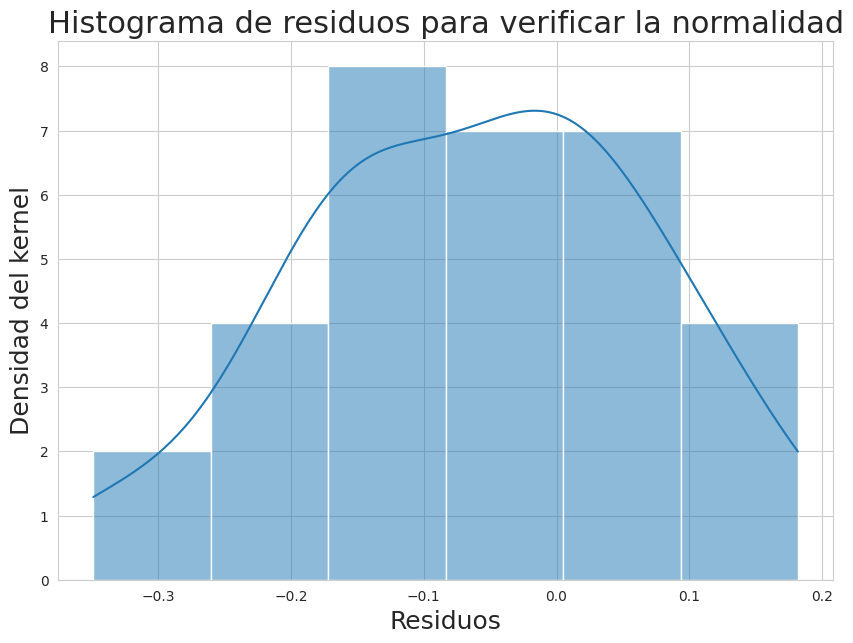

In [62]:
plt.figure(figsize=(10, 7))
plt.title("Histograma de residuos para verificar la normalidad", fontsize=22)
plt.xlabel("Residuos", fontsize=18)
plt.ylabel("Densidad del kernel", fontsize=18)
sns.histplot(y_test - predictions, kde=True)
plt.show()

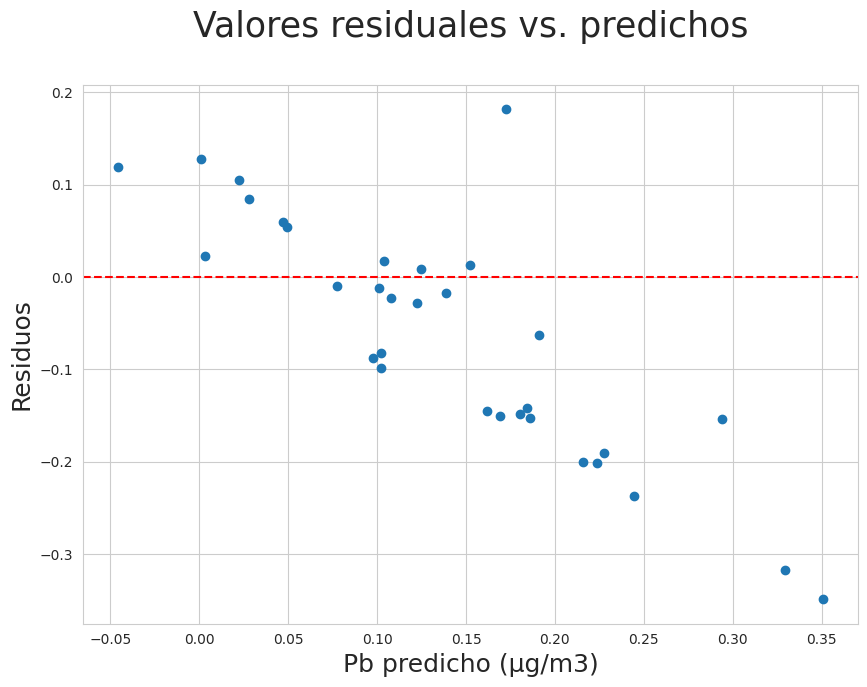

In [63]:
# Diagrama de dispersión de residuos
plt.figure(figsize=(10, 7))
plt.title("Valores residuales vs. predichos\n", fontsize=25)
plt.xlabel("Pb predicho (µg/m3)", fontsize=18)
plt.ylabel("Residuos", fontsize=18)
plt.scatter(x=predictions, y=y_test - predictions)
plt.axhline(y=0, color="r", linestyle="--")
plt.show()

Árbol de Decisión y Random Forest


*   Elemento de la lista
*   Elemento de la lista

La relación entre la fecha y la concentración de plomo no es estrictamente lineal, por lo que ahora probamos modelos basados en árboles, que sí pueden capturar relaciones no lineales.

In [64]:
from sklearn import tree
from sklearn.ensemble import RandomForestRegressor

<strong> Árbol de Decisión <strong>

In [65]:
# Creación del modelo (max_depth controla los niveles de decisión)
tree_model = tree.DecisionTreeRegressor(max_depth=5, random_state=10)
tree_model.fit(x_train, y_train)

DecisionTreeRegressor(max_depth=5, random_state=10)

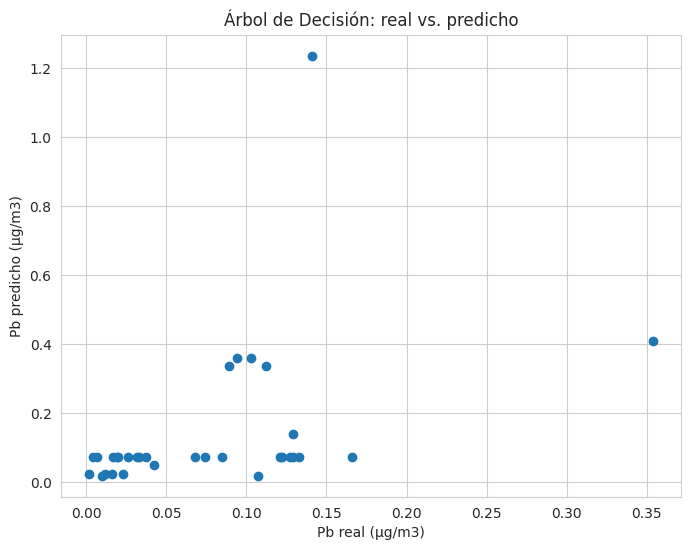

Mean square error (MSE): 0.0473
R2: -8.5821


In [66]:
# Hacemos predicciones con el árbol
test_pred_tree = tree_model.predict(x_test)
plt.figure(figsize=(8, 6))
plt.scatter(x=y_test, y=test_pred_tree)
plt.xlabel("Pb real (µg/m3)")
plt.ylabel("Pb predicho (µg/m3)")
plt.title("Árbol de Decisión: real vs. predicho")
plt.show()
print("Mean square error (MSE):", round(metrics.mean_squared_error(y_test, test_pred_tree), 4))
print("R2:", round(metrics.r2_score(y_test, test_pred_tree), 4))

<strong> Random Forest <strong>

In [67]:
rf_model = RandomForestRegressor(n_estimators=200, random_state=10)
rf_model.fit(x_train, y_train)
test_pred_rf = rf_model.predict(x_test)
print("MAE :", round(metrics.mean_absolute_error(y_test, test_pred_rf), 4))
print("MSE :", round(metrics.mean_squared_error(y_test, test_pred_rf), 4))
print("RMSE:", round(float(np.sqrt(metrics.mean_squared_error(y_test, test_pred_rf))), 4))
print("R2  :", round(metrics.r2_score(y_test, test_pred_rf), 4))

MAE : 0.0849
MSE : 0.0231
RMSE: 0.1521
R2  : -3.6842


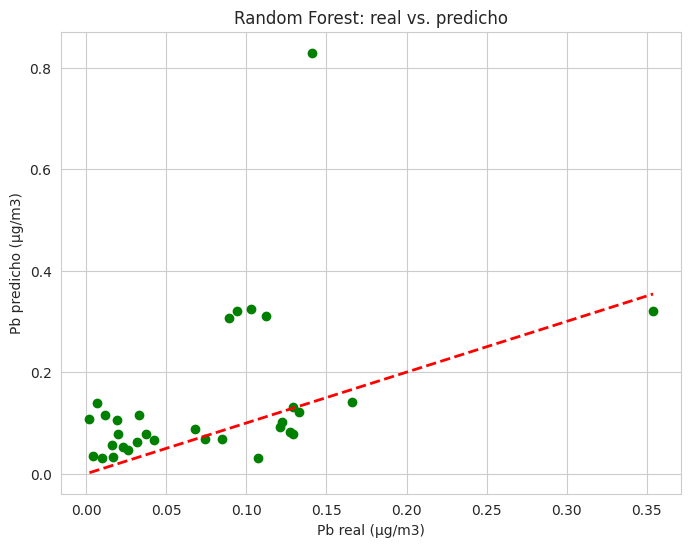

In [68]:
plt.figure(figsize=(8, 6))
plt.scatter(x=y_test, y=test_pred_rf, color="green")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--", linewidth=2)
plt.xlabel("Pb real (µg/m3)")
plt.ylabel("Pb predicho (µg/m3)")
plt.title("Random Forest: real vs. predicho")
plt.show()

<strong> Importancia relativa de las características <strong>

Importancia relativa de las características: [0.3514 0.3134 0.0203 0.1969 0.1115 0.0066]


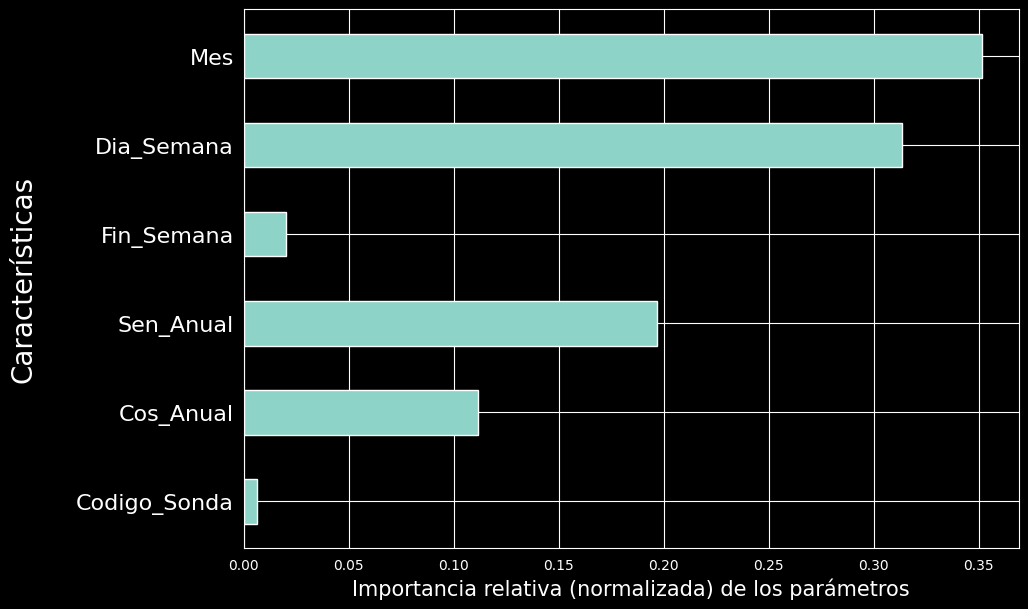

In [69]:
n_features = x_train.shape[1]
print("Importancia relativa de las características:", rf_model.feature_importances_.round(4))
with plt.style.context("dark_background"):
    plt.figure(figsize=(10, 7))
    plt.grid(True)
    plt.yticks(range(n_features, 0, -1), list(x_train.columns), fontsize=16)
    plt.xlabel("Importancia relativa (normalizada) de los parámetros", fontsize=15)
    plt.ylabel("Características\n", fontsize=20)
    plt.barh(range(n_features, 0, -1), width=rf_model.feature_importances_, height=0.5)
    plt.show()

# Comparación de los modelos

In [70]:
resultados = pd.DataFrame({
    "Modelo": ["Regresión Lineal", "Árbol de Decisión", "Random Forest"],
    "MAE": [metrics.mean_absolute_error(y_test, predictions),
            metrics.mean_absolute_error(y_test, test_pred_tree),
            metrics.mean_absolute_error(y_test, test_pred_rf)],
    "RMSE": [np.sqrt(metrics.mean_squared_error(y_test, predictions)),
             np.sqrt(metrics.mean_squared_error(y_test, test_pred_tree)),
             np.sqrt(metrics.mean_squared_error(y_test, test_pred_rf))],
    "R2": [metrics.r2_score(y_test, predictions),
           metrics.r2_score(y_test, test_pred_tree),
           metrics.r2_score(y_test, test_pred_rf)]
}).round(4)
resultados

,Modelo,MAE,RMSE,R2
0,Regresión Lineal,0.1125,0.1422,-3.0954
1,Árbol de Decisión,0.0988,0.2175,-8.5821
2,Random Forest,0.0849,0.1521,-3.6842


Resumen estadístico con statsmodels`statsmodels` entrega un reporte completo del modelo lineal: coeficientes, valores p, R², R² ajustado y pruebas de significancia, muy útil para interpretar estadísticamente el modelo.

In [71]:
import statsmodels.api as sm

In [72]:
Xs = sm.add_constant(x)
stat_model = sm.OLS(y, Xs)
stat_result = stat_model.fit()
print(stat_result.summary())

                            OLS Regression Results                            
Dep. Variable:                Pb_ugm3   R-squared:                       0.114
Model:                            OLS   Adj. R-squared:                  0.061
Method:                 Least Squares   F-statistic:                     2.128
Date:                Sat, 19 Sep 2026   Prob (F-statistic):             0.0566
Time:                        00:32:26   Log-Likelihood:                 33.517
No. Observations:                 106   AIC:                            -53.03
Df Residuals:                      99   BIC:                            -34.39
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const            0.1767      0.085      2.073   

#Conclusiones
* **Comportamiento estacional:** La concentración de plomo en la estación TROY LEAD muestra variación a lo largo del año, con el valor más alto observado en noviembre en este conjunto de datos.
* **Variables clave:** Las variables asociadas al **momento del año** (`Mes`, `Sen_Anual` y `Cos_Anual`) y al día de la semana (`Dia_Semana`) muestran algo de relación con el plomo, aunque las correlaciones son en general débiles.
* **Limitación del modelo lineal:** La **Regresión Lineal** explica muy poco de la variación observada, en parte porque el conjunto de datos es pequeño (106 registros, una muestra por semana aproximadamente).
* **Modelos no lineales:** Los modelos basados en árboles (**Árbol de Decisión** y **Random Forest**) no logran superar claramente al modelo lineal con tan pocos datos disponibles.
* **Oportunidades de mejora:** Para incrementar la precisión del modelo, se recomienda contar con más años de mediciones y variables externas como **fuentes industriales cercanas, tráfico vehicular y condiciones meteorológicas**.